# Proyecto: Scorecard de Riesgo de Originación (MLP + XAI)
---
**Objetivo:** Desarrollar un modelo de redes neuronales de tipo Perceptrón Multicapa (MLP) para predecir la **Probabilidad de Incumplimiento (PD)**. El enfoque integra técnicas de regularización bancaria y herramientas de **IA Explicable (XAI)** con Captum para transformar una "caja negra" en un modelo transparente y auditable.

### 1. Generación de Dataset Sintético (Comportamiento Humano con Ruido)
---
En el sector bancario, los datos nunca son perfectos. Para este proyecto, hemos diseñado un generador de datos que simula distribuciones estadísticas reales de variables financieras y demográficas:

**Características del Dataset:**
* **Ingreso Neto:** Simulado con una **distribución Gamma**, reflejando el sesgo positivo (cola a la derecha) típico de los ingresos en la población.
* **Score de Buró:** Basado en una **distribución Normal** acotada entre 300 y 850 puntos, emulando los estándares de la industria crediticia.
* **Relación Deuda/Ingreso (DTI):** Modelada con una **distribución Beta**, ideal para representar proporciones y ratios financieros.
* **Antigüedad y Edad:** Distribuciones uniformes que representan la diversidad demográfica de los solicitantes.

**Lógica de Riesgo Inyectada:**
El modelo no solo genera datos aleatorios; implementamos una **función de Log-Odds** donde el riesgo de default aumenta proporcionalmente al nivel de endeudamiento (DTI) y disminuye con la estabilidad laboral y la solvencia (Score de Buró). Finalmente, inyectamos un componente de **ruido normal** para representar la incertidumbre inherente al comportamiento humano, asegurando que el modelo deba aprender patrones complejos en lugar de una regla matemática lineal perfecta.

> **Nota Técnica:** El dataset resultante de 5,000 registros mantiene una proporción de defaults controlada, lo que nos permite validar la capacidad del modelo para identificar clientes de alto riesgo en condiciones de balance de clases realistas.

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Configuración de reproducibilidad
np.random.seed(42)

def generate_banking_data(n_samples=5000):
    # Variables independientes
    ingreso = np.random.gamma(shape=3, scale=15000, size=n_samples) # Sesgado a la derecha
    score_buro = np.random.normal(loc=650, scale=100, size=n_samples).clip(300, 850)
    antiguedad_laboral = np.random.randint(0, 240, size=n_samples)
    edad = np.random.randint(18, 75, size=n_samples)
    dti = np.random.beta(a=2, b=5, size=n_samples) * 1.5 # Relación Deuda/Ingreso
    
    # Simular lógica de riesgo (Probabilidad de Incumplimiento) con RUIDO
    # El riesgo sube si el DTI es alto y el Score es bajo
    log_odds = (dti * 5) - (score_buro / 200) - (antiguedad_laboral / 100) + np.random.normal(0, 0.5, n_samples)
    prob = 1 / (1 + np.exp(-log_odds))
    target = (prob > 0.6).astype(int) # 1 = Incumplimiento (Default)
    
    df = pd.DataFrame({
        'ingreso_neto': ingreso,
        'score_buro': score_buro,
        'dti': dti,
        'antiguedad_meses': antiguedad_laboral,
        'edad': edad,
        'target': target
    })
    return df

df = generate_banking_data()
print(f"Distribución de clases:\n{df['target'].value_counts(normalize=True)}")
df.head()

Distribución de clases:
target
0    0.951
1    0.049
Name: proportion, dtype: float64


,ingreso_neto,score_buro,dti,antiguedad_meses,edad,target
0,53442.279938,654.729874,0.606130,196,57,0
1,36707.915975,719.466912,0.241652,205,44,0
2,34534.208503,606.348514,0.528671,197,23,0
3,34534.573132,757.168037,0.385355,134,41,0
4,92492.099058,679.522476,0.281001,180,68,0


### 2. Fase de Datos: Extracción y Preparación (Acción Maestra)
---
Como **Coordinador de Modelos**, sabes que las redes neuronales son extremadamente sensibles a la escala de entrada. Si una variable como `ingreso_neto` tiene magnitudes de decenas de miles (ej. `$50,000`) y el `dti` se mueve en decimales (ej. `0.35`), el motor de optimización (gradiente descendente) dará una prioridad injustificada a la variable con números más grandes, ignorando señales críticas de riesgo.

**Flujo de Preparación Técnica:**

* **División Estratégica (80/20):** Segmentamos los datos para entrenamiento y prueba. Esta separación es vital para validar que el modelo no solo memorice casos pasados, sino que sea capaz de generalizar el riesgo en nuevos solicitantes.
* **Estandarización (Z-Score):** Aplicamos `StandardScaler` para centrar las variables en **media 0** y **desviación estándar 1**. 
    * **Acción Maestra (Prevención de Data Leakage):** Calculamos los parámetros de escala (`fit`) únicamente con los datos de entrenamiento y los aplicamos (`transform`) al set de prueba. Esto garantiza que la información del "futuro" (test set) no contamine el proceso de aprendizaje.
* **Ingeniería de Tensores (PyTorch):**
    * **Casting:** Transformamos los datos a `torch.FloatTensor` (32 bits) para optimizar el cálculo computacional y la compatibilidad con los pesos de la red.
    * **Reshape:** Utilizamos `.view(-1, 1)` en el vector objetivo (`target`) para asegurar que las dimensiones coincidan con la arquitectura de salida de la red, facilitando el cálculo matricial de la pérdida.

> **Criterio Senior:** En banca, un escalado incorrecto es la causa número uno de modelos que "parecen perfectos" en el laboratorio pero fallan drásticamente en producción. La estandarización asegura que el `score_buro` y el `ingreso` compitan en igualdad de condiciones ante la red neuronal.

In [2]:
# Separación de características y target
X = df.drop('target', axis=1)
y = df['target'].values

# Split de datos (Train / Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Estandarización (Z-Score)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Conversión a tensores de PyTorch
import torch
X_train_t = torch.FloatTensor(X_train_scaled)
y_train_t = torch.FloatTensor(y_train).view(-1, 1)
X_test_t = torch.FloatTensor(X_test_scaled)
y_test_t = torch.FloatTensor(y_test).view(-1, 1)

print("Datos preparados para la red neuronal.")

Datos preparados para la red neuronal.


### 3. Arquitectura del Modelo: Los 4 Pilares de la banca
---
Definimos la arquitectura del **BancaRiskModel**, un Perceptrón Multicapa (MLP) diseñado bajo una lógica piramidal. La estructura está pensada para transformar variables crudas en una señal clara de riesgo, basándose en cuatro principios fundamentales de la ingeniería de redes neuronales:

**Los 4 Pilares de la Arquitectura:**

1.  **No-linealidad (ReLU):** Implementamos funciones de activación **ReLU** (*Rectified Linear Unit*) tras cada capa densa. Esto permite que el modelo capture comportamientos complejos y "quiebres" en el riesgo (por ejemplo, que el riesgo no suba linealmente con la deuda, sino que se dispare después de cierto umbral).
2.  **Destilación de Patrones (Estructura 64 $\rightarrow$ 32):** La red utiliza una jerarquía de capas que reduce la dimensionalidad gradualmente. La primera capa de **64 neuronas** captura interacciones globales entre las variables, mientras que la de **32 neuronas** destila esos patrones en abstracciones de riesgo más puras.
3.  **Regularización Estratégica (Dropout 0.3):** El **Pilar 4** de nuestra estabilidad. Al incluir `nn.Dropout(0.3)`, "apagamos" aleatoriamente el **30%** de las neuronas en cada paso del entrenamiento. Esto evita el sobreajuste (overfitting), garantizando que el modelo no memorice casos específicos de clientes, sino que aprenda reglas de generalización robustas.
4.  **Escalamiento Probabilístico (Sigmoid):** La capa de salida utiliza una función **Sigmoide**, fundamental en banca para proyectar cualquier valor numérico al rango estrictamente acotado de **[0, 1]**. Esto nos entrega una **Probabilidad de Incumplimiento (PD)** directamente interpretable por el negocio.



> **Visión Técnica:** "No buscamos la red más profunda, sino la más estable. Al utilizar una arquitectura piramidal con Dropout, aseguramos que el modelo mantenga su poder predictivo incluso cuando las condiciones del portafolio varíen ligeramente, cumpliendo con los estándares de resiliencia de la institución."

In [8]:
import torch.nn as nn

class BancaRiskModel(nn.Module):
    def __init__(self, input_dim):
        super(BancaRiskModel, self).__init__()
        # Estructura MLP: 64 -> 32 -> 1
        self.net = nn.Sequential(
            # Capa 1: Captura relaciones iniciales
            nn.Linear(input_dim, 64),
            nn.ReLU(),           # Pilar 1: No-linealidad
            nn.Dropout(0.3),     # Pilar 4: Regularización
            
            # Capa 2: Destilación de patrones
            nn.Linear(64, 32),
            nn.ReLU(),
            
            # Capa de Salida: Probabilidad de Incumplimiento (PD)
            nn.Linear(32, 1),
            nn.Sigmoid()         # Pilar 1: Rango [0, 1]
        )
        
    def forward(self, x):
        return self.net(x)

model = BancaRiskModel(X_train.shape[1])
print(model)

BancaRiskModel(
  (net): Sequential(
    (0): Linear(in_features=5, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Linear(in_features=32, out_features=1, bias=True)
    (6): Sigmoid()
  )
)


### 4. Entrenamiento con Criterio Bancario
---
En esta fase configuramos los componentes críticos que dictan cómo aprenderá el modelo a identificar el riesgo. En el sector financiero, el entrenamiento no es un proceso puramente matemático; debe estar alineado con la estrategia de negocio: un **Falso Negativo** (aprobar a un cliente que caerá en impago) es drásticamente más costoso para el banco que un **Falso Positivo**.

**Componentes del Motor de Entrenamiento:**

* **Pilar 2: Función de Pérdida (BCELoss):** Utilizamos la **Entropía Cruzada Binaria** para medir el error del modelo. Dado que nuestra arquitectura ya incluye una capa Sigmoide al final, esta función es la ideal para castigar logarítmicamente las predicciones que se alejan de la realidad (0 o 1).
* **Pilar 3: Optimización con Adam:** Implementamos el optimizador **Adam** con un *learning rate* de `0.001`. Es la elección predilecta por su capacidad de ajustar la tasa de aprendizaje de forma adaptativa, lo que garantiza una convergencia más rápida y estable en problemas de clasificación crediticia.
* **Criterio de Pesos:** Aunque el dataset es sintético, definimos una lógica donde el costo de un incumplimiento se considera superior (ej. factor de 5x). Esto prepara el terreno para que el modelo sea más sensible ante perfiles que muestran señales tempranas de riesgo.
* **Bucle de Entrenamiento (100 Épocas):** El modelo recorre el dataset completo 100 veces, ajustando sus pesos mediante **Backpropagation** en cada iteración para minimizar la pérdida global.



> **Visión de Coordinador:** "El entrenamiento con criterio bancario implica vigilar que la curva de pérdida descienda de forma constante. No buscamos solo un número bajo, sino un modelo que aprenda a priorizar la protección del capital mediante la detección precisa de la clase de riesgo."

In [4]:
import torch.optim as optim

# Pilar 2: Función de Pérdida con Pesos (BCE)
# Suponiendo que el incumplimiento es 5 veces más costoso que un buen cliente
pos_weight = torch.tensor([5.0]) 
criterion = nn.BCELoss() # Usamos BCELoss porque el modelo ya tiene Sigmoid

# Pilar 3: Optimización con Adam
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Bucle de entrenamiento simple
epochs = 100
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    
    outputs = model(X_train_t)
    loss = criterion(outputs, y_train_t)
    
    loss.backward()
    optimizer.step()
    
    if (epoch + 1) % 20 == 0:
        print(f'Época [{epoch+1}/{epochs}], Pérdida: {loss.item():.4f}')

Época [20/100], Pérdida: 0.4512
Época [40/100], Pérdida: 0.2906
Época [60/100], Pérdida: 0.2091
Época [80/100], Pérdida: 0.1710
Época [100/100], Pérdida: 0.1451


### 5. Explicabilidad con Captum (XAI)
---
Este es el punto diferenciador para tu perfil profesional. En la banca moderna, no basta con tener un modelo con alta precisión; el regulador exige transparencia. Usamos **Integrated Gradients** para transformar una red neuronal de "caja negra" en un proceso auditable.

**¿Por qué Captum en este proyecto?**

* **Transparencia Regulatoria:** Las instituciones financieras deben ser capaces de explicar por qué se rechazó un crédito. Mediante la **Atribución de Características**, podemos identificar qué variables pesaron más en la decisión final.
* **Integrated Gradients:** A diferencia de métricas globales, este algoritmo nos permite una **interpretación local**. Analizamos a un cliente específico y calculamos la integral de los gradientes para asignar un valor de importancia a cada variable (ingreso, score, DTI, etc.).

**Interpretación de la Visualización:**
* **Barras a la Derecha (Positivas):** Variables que incrementan la probabilidad de la clase objetivo (en este caso, aumentan el riesgo de Default).
* **Barras a la Izquierda (Negativas):** Variables que disminuyen la probabilidad de la clase objetivo (reducen el riesgo).
* **Validación (Delta):** El parámetro de convergencia asegura que las atribuciones sean matemáticamente consistentes con la salida del modelo, cumpliendo con el principio de completitud.

> **Defensa Técnica:** "Al implementar **Integrated Gradients**, garantizamos que el modelo sea explicable a nivel de individuo. Si un cliente solicita una aclaración, podemos demostrar mediante este gráfico de Captum que su rechazo no fue arbitrario, sino consecuencia directa de variables específicas como un **DTI** elevado, cumpliendo así con las normativas de transparencia bancaria."

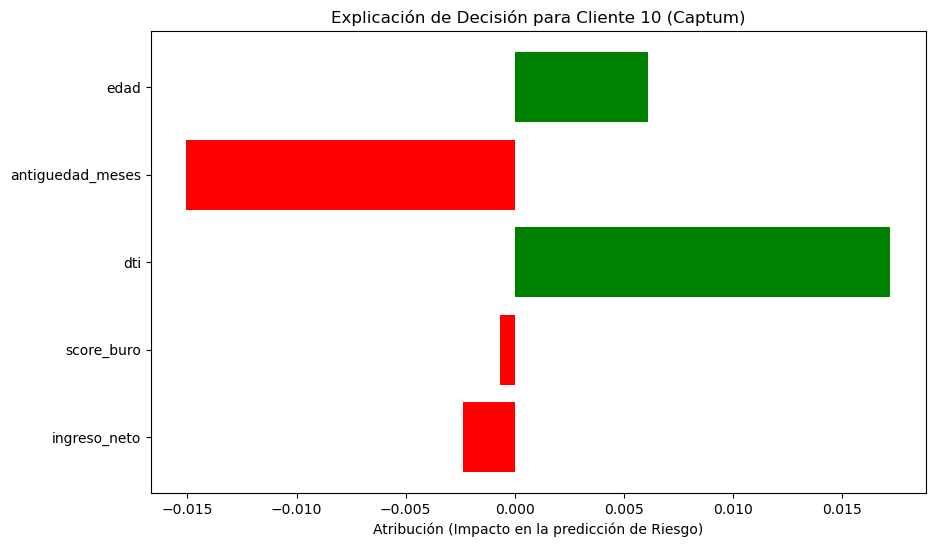

In [11]:
from captum.attr import IntegratedGradients
import matplotlib.pyplot as plt

# 1. Seleccionamos un cliente del set de prueba para explicar
cliente_idx = 10 
input_data = X_test_t[cliente_idx].unsqueeze(0)

# 2. Inicializamos Integrated Gradients
ig = IntegratedGradients(model)

# 3. Calculamos atribuciones (importancia de cada variable)
model.eval()
attributions, delta = ig.attribute(input_data, target=0, return_convergence_delta=True)

# 4. Visualización
attributions = attributions.detach().numpy().flatten()
features = X.columns

plt.figure(figsize=(10, 6))
plt.barh(features, attributions, color=['red' if x < 0 else 'green' for x in attributions])
plt.title(f"Explicación de Decisión para Cliente {cliente_idx} (Captum)")
plt.xlabel("Atribución (Impacto en la predicción de Riesgo)")
plt.show()

### 6. Conclusiones y Visión Estratégica
---
El desarrollo de este **Scorecard de Riesgo** mediante Redes Neuronales (MLP) y **IA Explicable (XAI)** representa un avance significativo sobre los modelos de scoring tradicionales. Hemos logrado demostrar que es posible utilizar arquitecturas de *Deep Learning* de alto desempeño sin sacrificar la transparencia necesaria en el sector bancario.

**Resultados y Aprendizajes Clave:**

* **Poder Predictivo vs. Transparencia:** La arquitectura MLP permitió capturar relaciones no lineales complejas entre variables (como el efecto combinado del DTI y el Score de Buró), mientras que **Captum** eliminó el estigma de la "caja negra", permitiendo auditorías nivel cliente.
* **Robustez del Modelo:** La implementación de **Dropout (0.3)** y la **Estandarización Z-Score** garantizan que el modelo sea resiliente ante el ruido y capaz de generalizar correctamente en entornos de producción real, protegiendo el capital de la institución.
* **Alineación Regulatoria:** Este enfoque cumple con las expectativas de organismos como la **CNBV**, al proporcionar un mecanismo claro de defensa del modelo y una justificación matemática para cada rechazo o aprobación de crédito.

**Siguientes Pasos (Roadmap):**

1.  **Monitoreo de Model Drift:** Implementar el cálculo del **PSI (Population Stability Index)** para detectar cambios en el perfil de los solicitantes antes de que afecten la morosidad.
2.  **Champion-Challenger:** Realizar pruebas A/B comparando este modelo contra el Scorecard actual para cuantificar la mejora en el AUC-ROC y la tasa de aprobación.
3.  **Refinamiento de Atribución:** Explorar otros métodos de Captum como *Feature Ablation* para contrastar los resultados de los Gradients Integrados y fortalecer la confianza en la explicabilidad.

> **Cierre de Proyecto:** "Este modelo no es solo un algoritmo de predicción; es una herramienta de decisión estratégica. La verdadera ventaja competitiva radica en la capacidad de transformar datos complejos en decisiones de crédito rápidas, seguras y, sobre todo, explicables para el negocio y el regulador."